# 14) Results Write-up (Markdown + Figures)

このノートブックは、本研究の **分析結果（表・図）** と **考察** を、卒論/発表用にMarkdown形式でまとめたものです。

- **主結果**：リスク開示の新規性（`change_topk`）は、株価（CAR）よりも **出来高（注目度）** と **不確実性（|AR|）** に強く反応
- **カテゴリ別**：地政学（`change_topk_geo`）は出来高（`abvol_mkt`）で有意

> 実行：上から Run All。DB（Postgres）が起動している前提。



In [6]:
import os
from dataclasses import dataclass

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

import matplotlib.pyplot as plt

# optional
try:
    import statsmodels.api as sm
except Exception:
    sm = None

plt.rcParams["figure.figsize"] = (10, 4)



In [7]:
def find_project_root(start_dir: str) -> str:
    d = os.path.abspath(start_dir)
    while True:
        if os.path.exists(os.path.join(d, "docker-compose.yml")) and os.path.exists(os.path.join(d, "requirements.txt")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            return os.path.abspath(start_dir)
        d = parent


PROJECT_ROOT = find_project_root(os.getcwd())
os.chdir(PROJECT_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT)

load_dotenv(dotenv_path=os.path.join(PROJECT_ROOT, ".env"))
DB_USER = os.getenv("POSTGRES_USER")
DB_PASS = os.getenv("POSTGRES_PASSWORD")
DB_HOST = os.getenv("POSTGRES_HOST", "localhost")
DB_PORT = os.getenv("POSTGRES_PORT", "5432")
DB_NAME = os.getenv("POSTGRES_DB")

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("DB connected")

DATA_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
OUT_FIG = os.path.join(PROJECT_ROOT, "outputs", "figures")
OUT_TAB = os.path.join(PROJECT_ROOT, "outputs", "results")
os.makedirs(OUT_FIG, exist_ok=True)
os.makedirs(OUT_TAB, exist_ok=True)

TOPIX500_CATEGORIES = {"TOPIX Core30", "TOPIX Large70", "TOPIX Mid400"}

# --- runtime config ---
SAMPLE_MODE = True
SAMPLE_N = 7336  # fast, close to full; set larger / False for full run
SAMPLE_SEED = 42

EVENT_WINDOWS = {"m1_p1": (-1, 1)}  # for write-up we focus on the main window
EST_WINDOW = (-120, -21)
CUTOFF_HOUR = 15
MIN_EST_OBS = 60

print("SAMPLE_MODE=", SAMPLE_MODE, "SAMPLE_N=", SAMPLE_N)



PROJECT_ROOT: /home/junxzi/dev/risk-novelty-stock-jp
DB connected
SAMPLE_MODE= True SAMPLE_N= 7336


## データと指標

- **テキスト**：EDINET 有価証券報告書「事業等のリスク」
- **市場データ**：J-Quants 日次株価・出来高
- **統制変数**：総資産・売上高・ROA・レバレッジ（年FE/業種FE）

### 新規性（novelty）の定義（要旨）
- リスク文をチャンクに分割し、前年チャンク群との **最大類似度**を計算
- 変化度：\(1-\max\_sim\)
- 上位k%平均：`change_topk`

### アウトカム
- `abvol_mkt`：市場平均出来高で調整した log-volume をイベント窓で合計（注目度）
- `vol_abs`：市場モデルのARの \(\sum |AR|\)（不確実性）
- `car_mm`：市場モデルCAR（参考：弱い）



In [8]:
def load_topix_membership(years: list[int]) -> dict[int, list[str]]:
    out: dict[int, list[str]] = {}
    for y in years:
        p = os.path.join(DATA_DIR, f"topix_companies_{y}.csv")
        m = pd.read_csv(p)
        m["security_code"] = m["security_code"].astype(str).str.zfill(5)
        if "scale_category" in m.columns:
            m = m[m["scale_category"].isin(TOPIX500_CATEGORIES)]
        out[y] = sorted(m["security_code"].dropna().unique().tolist())
    return out


def load_company_snapshot(years: list[int]) -> pd.DataFrame:
    frames = []
    for y in years:
        p = os.path.join(DATA_DIR, f"topix_companies_{y}.csv")
        t = pd.read_csv(p)
        t["security_code"] = t["security_code"].astype(str).str.zfill(5)
        t["year"] = int(y)
        frames.append(t)
    snap = pd.concat(frames, ignore_index=True)
    keep = ["year", "security_code"]
    for c in ["sector_17", "sector_33", "scale_category", "market_code", "name_ja"]:
        if c in snap.columns:
            keep.append(c)
    return snap[keep].drop_duplicates(["year", "security_code"])


def build_market_return(quotes: pd.DataFrame, membership_by_year: dict[int, list[str]]) -> pd.Series:
    rm_frames = []
    for y, codes in membership_by_year.items():
        sub = quotes[quotes["code"].isin(codes)][["date", "ret"]].dropna()
        if sub.empty:
            continue
        rm = sub.groupby("date")["ret"].mean().rename("rm").reset_index()
        rm["year"] = y
        rm_frames.append(rm)
    rm = pd.concat(rm_frames, ignore_index=True).sort_values("date")
    rm = rm.drop_duplicates("date", keep="last")
    return rm.set_index("date")["rm"]


def next_td(g: pd.DataFrame, day: pd.Timestamp) -> pd.Timestamp | None:
    i = g["date"].searchsorted(day, side="left")
    if i >= len(g):
        return None
    return g.loc[i, "date"]


def shift_td(g: pd.DataFrame, day: pd.Timestamp, k: int) -> pd.Timestamp | None:
    i = g["date"].searchsorted(day, side="left")
    if i >= len(g):
        return None
    j = i + k
    if j < 0 or j >= len(g):
        return None
    return g.loc[j, "date"]


def estimate_alpha_beta(stock_ret: pd.DataFrame, rm: pd.Series, event_day: pd.Timestamp, est_window: tuple[int, int], min_obs: int):
    s = shift_td(stock_ret, event_day, est_window[0])
    e = shift_td(stock_ret, event_day, est_window[1])
    if s is None or e is None:
        return None
    est = stock_ret[(stock_ret["date"] >= s) & (stock_ret["date"] <= e)].copy()
    est = est.join(rm, on="date", how="inner").dropna(subset=["ret", "rm"])
    if len(est) < min_obs:
        return None
    x = est["rm"].to_numpy()
    y = est["ret"].to_numpy()
    X = np.column_stack([np.ones_like(x), x])
    a, b = np.linalg.lstsq(X, y, rcond=None)[0]
    return float(a), float(b)


def event_window_panel(
    stock_df: pd.DataFrame,
    rm: pd.Series,
    submit_ts: pd.Timestamp,
    window: tuple[int, int],
    cutoff_hour: int,
    est_window: tuple[int, int],
    min_est_obs: int,
):
    base = pd.Timestamp(submit_ts.date())
    ev = next_td(stock_df, base)
    if ev is None:
        return None
    if submit_ts.hour >= cutoff_hour:
        ev = shift_td(stock_df, ev, 1)
        if ev is None:
            return None

    ab = estimate_alpha_beta(stock_df[["date", "ret"]].dropna().reset_index(drop=True), rm, ev, est_window, min_est_obs)
    if ab is None:
        return None
    a, b = ab

    s = shift_td(stock_df, ev, window[0])
    e = shift_td(stock_df, ev, window[1])
    if s is None or e is None:
        return None

    cols = ["date", "ret"]
    for c in ["log_vol", "avol"]:
        if c in stock_df.columns:
            cols.append(c)

    evdf = stock_df[(stock_df["date"] >= s) & (stock_df["date"] <= e)][cols].copy()
    evdf = evdf.join(rm, on="date", how="inner").dropna(subset=["ret", "rm"])
    if evdf.empty:
        return None

    evdf["ar"] = evdf["ret"] - (a + b * evdf["rm"])
    return evdf


def summarize_uncertainty(evdf: pd.DataFrame):
    ar = evdf["ar"].astype(float)
    return {
        "car_mm": float(ar.sum()),
        "vol_abs": float(np.abs(ar).sum()),
        "vol_sq": float((ar**2).sum()),
        "downside": float(ar.min()),
        "abvol_mkt": float(evdf["avol"].dropna().sum()) if "avol" in evdf.columns else np.nan,
        "n_days": int(len(evdf)),
    }


def safe_log(x):
    x = pd.to_numeric(x, errors="coerce")
    return np.log(x.replace(0, np.nan))


def run_ols(
    df: pd.DataFrame,
    y_col: str,
    novelty_col: str,
    label: str,
    extra_controls: list[str] | None = None,
    add_company_fe: bool = False,
    cluster_company: bool = True,
) -> dict:
    if sm is None:
        raise RuntimeError("statsmodels not available")

    extra_controls = extra_controls or []

    req = [y_col, novelty_col, "log_assets", "log_revenue", "roa", "lev", "fiscal_year", "sector_17"] + list(extra_controls)
    if add_company_fe:
        req.append("company_id")

    base = df.dropna(subset=req).copy()

    y = pd.to_numeric(base[y_col], errors="coerce").astype(float)

    x_cols = [novelty_col, "log_assets", "log_revenue", "roa", "lev"] + list(extra_controls)
    X = base[x_cols].apply(pd.to_numeric, errors="coerce")
    X = X.rename(columns={novelty_col: "novelty"})

    X = pd.concat(
        [X, pd.get_dummies(base["fiscal_year"].astype(int), prefix="fy", drop_first=True, dtype=float)],
        axis=1,
    )
    X = pd.concat(
        [X, pd.get_dummies(base["sector_17"].fillna("unknown").astype(str), prefix="sec", drop_first=True, dtype=float)],
        axis=1,
    )

    if add_company_fe:
        X = pd.concat(
            [X, pd.get_dummies(base["company_id"].astype(str), prefix="comp", drop_first=True, dtype=float)],
            axis=1,
        )

    X = sm.add_constant(X, has_constant="add")

    reg = pd.concat([y.rename("y"), X], axis=1)

    groups = None
    if cluster_company and ("company_id" in base.columns):
        reg = pd.concat([reg, base["company_id"].astype(str).rename("company_id")], axis=1)
        reg = reg.dropna()
        groups = reg["company_id"]
        exog = reg.drop(columns=["y", "company_id"])
    else:
        reg = reg.dropna()
        exog = reg.drop(columns=["y"])

    res = sm.OLS(reg["y"], exog)

    if cluster_company and groups is not None:
        fit = res.fit(cov_type="cluster", cov_kwds={"groups": groups})
        se = "cluster(company)"
    else:
        fit = res.fit(cov_type="HC1")
        se = "HC1"

    return {
        "label": label,
        "y": y_col,
        "n": int(len(reg)),
        "beta": float(fit.params.get("novelty", np.nan)),
        "t": float(fit.tvalues.get("novelty", np.nan)),
        "p": float(fit.pvalues.get("novelty", np.nan)),
        "r2": float(fit.rsquared),
        "company_fe": bool(add_company_fe),
        "se": se,
    }



In [9]:
# --- 1) Load novelty scores + meta + controls ---

SCORES_COLS = [
    "company_id::uuid as company_id",
    "fiscal_year",
    "doc_id_curr",
    "change_topk",
    "change_topk_geo",
    "change_topk_cyber",
    "change_topk_human",
    "change_topk_disaster",
    "change_topk_reg",
]

scores = pd.read_sql("select " + ", ".join(SCORES_COLS) + " from risk_change_scores", engine)
print("risk_change_scores:", len(scores))

if SAMPLE_MODE:
    scores = scores.sample(n=min(SAMPLE_N, len(scores)), random_state=SAMPLE_SEED).copy()
    print("sampled:", len(scores))

meta = pd.read_sql(
    text(
        """
        select d.doc_id, d.submit_date, c.security_code
        from edinet_documents d
        join companies c on c.company_id = d.company_id
        where d.doc_id = any(:doc_ids)
        """
    ),
    engine,
    params={"doc_ids": scores["doc_id_curr"].tolist()},
)
meta["submit_ts"] = pd.to_datetime(meta["submit_date"])
meta["security_code"] = meta["security_code"].astype(str).str.zfill(5)

base = scores.merge(meta[["doc_id", "submit_ts", "security_code"]], left_on="doc_id_curr", right_on="doc_id", how="left")
base = base.dropna(subset=["submit_ts", "security_code"]).copy()
base["year"] = base["submit_ts"].dt.year

controls = pd.read_sql(
    """
    select company_id::uuid as company_id, fiscal_year,
           total_assets, total_liabilities, net_assets, revenue, operating_income, net_income
    from edinet_controls
    """,
    engine,
)
base = base.merge(controls, on=["company_id", "fiscal_year"], how="left")

needed_years = sorted(base["year"].dropna().astype(int).unique().tolist())
membership_by_year = load_topix_membership(needed_years)
snap = load_company_snapshot(needed_years)
base = base.merge(snap, on=["year", "security_code"], how="left")

# controls transforms
base["log_assets"] = safe_log(base["total_assets"])
base["log_revenue"] = safe_log(base["revenue"])
base["roa"] = pd.to_numeric(base["net_income"], errors="coerce") / pd.to_numeric(base["total_assets"], errors="coerce")
base["lev"] = pd.to_numeric(base["total_liabilities"], errors="coerce") / pd.to_numeric(base["total_assets"], errors="coerce")

print("base docs:", len(base), "unique docs:", base["doc_id_curr"].nunique())
base[["change_topk", "change_topk_geo", "fiscal_year"]].describe()



risk_change_scores: 7336
sampled: 7336
base docs: 7336 unique docs: 7336


,change_topk,change_topk_geo,fiscal_year
count,7.336000e+03,4.850000e+03,7336.000000
mean,1.863543e-01,1.777269e-01,2021.731189
std,1.327330e-01,2.303634e-01,2.243947
min,-1.192093e-07,-2.384186e-07,2018.000000
25%,5.742448e-02,4.167855e-04,2020.000000
50%,1.951169e-01,1.241221e-01,2022.000000
75%,2.666256e-01,2.502075e-01,2024.000000
max,6.719558e-01,1.000000e+00,2025.000000


In [10]:
# --- 2) Build / load event-study dataset (cached) ---
# NOTE: We use pickle instead of parquet to avoid pyarrow extension-type issues
# (e.g., ArrowKeyError: No type extension with name arrow.py_extension_type found)

CACHE_TAG = f"writeup_sample{int(SAMPLE_MODE)}_n{len(base)}_seed{SAMPLE_SEED}_winm1p1"
CACHE_PATH = os.path.join(DATA_DIR, f"writeup_event_dataset_{CACHE_TAG}.pkl")
print("CACHE_PATH:", CACHE_PATH)

if os.path.exists(CACHE_PATH):
    out = pd.read_pickle(CACHE_PATH)
    print("loaded cached dataset:", len(out))
else:
    # date range for quotes
    min_day = base["submit_ts"].dt.floor("D").min() - pd.Timedelta(days=450)
    max_day = base["submit_ts"].dt.floor("D").max() + pd.Timedelta(days=30)

    stock_codes = sorted(base["security_code"].unique().tolist())
    market_codes = sorted(set(sum((membership_by_year[y] for y in needed_years), [])))
    all_codes = sorted(set(stock_codes) | set(market_codes))

    quotes = pd.read_sql(
        text(
            """
            select code, date, adjusted_close, adjusted_volume
            from daily_quotes
            where code = any(:codes) and date between :d0 and :d1
            order by code, date
            """
        ),
        engine,
        params={"codes": all_codes, "d0": min_day.date(), "d1": max_day.date()},
    )
    quotes["code"] = quotes["code"].astype(str).str.zfill(5)
    quotes["date"] = pd.to_datetime(quotes["date"])
    quotes["adjusted_close"] = pd.to_numeric(quotes["adjusted_close"], errors="coerce")
    quotes["adjusted_volume"] = pd.to_numeric(quotes["adjusted_volume"], errors="coerce")
    quotes = quotes.dropna(subset=["adjusted_close"]).sort_values(["code", "date"]).copy()
    quotes["ret"] = quotes.groupby("code")["adjusted_close"].pct_change()
    quotes["log_vol"] = np.log(quotes["adjusted_volume"].where(quotes["adjusted_volume"] > 0))

    # market mean volume (cross-sectional baseline)
    mkt_vol = quotes[quotes["code"].isin(market_codes)][["date", "adjusted_volume"]].dropna()
    if not mkt_vol.empty:
        mkt_mean_vol = mkt_vol.groupby("date")["adjusted_volume"].mean().rename("mkt_mean_vol")
    else:
        mkt_mean_vol = pd.Series(dtype=float, name="mkt_mean_vol")

    stock_by = {}
    for c, g in quotes[quotes["code"].isin(stock_codes)].groupby("code"):
        gg = g[["date", "ret", "log_vol"]].copy()
        if not mkt_mean_vol.empty:
            gg = gg.join(mkt_mean_vol, on="date", how="left")
            gg["avol"] = gg["log_vol"] - np.log(gg["mkt_mean_vol"])
        stock_by[c] = gg.dropna(subset=["ret"]).reset_index(drop=True)

    rm = build_market_return(quotes.dropna(subset=["ret"]).copy(), membership_by_year)

    rows = []
    for r in base.itertuples(index=False):
        code = str(r.security_code)
        stock_ret = stock_by.get(code)
        if stock_ret is None or stock_ret.empty:
            continue
        submit_ts = pd.to_datetime(r.submit_ts)

        win = EVENT_WINDOWS["m1_p1"]
        evdf = event_window_panel(
            stock_df=stock_ret,
            rm=rm,
            submit_ts=submit_ts,
            window=win,
            cutoff_hour=CUTOFF_HOUR,
            est_window=EST_WINDOW,
            min_est_obs=MIN_EST_OBS,
        )
        if evdf is None or evdf.empty:
            continue

        unc = summarize_uncertainty(evdf)
        rows.append(
            {
                "company_id": r.company_id,
                "fiscal_year": int(r.fiscal_year),
                "doc_id_curr": r.doc_id_curr,
                "security_code": code,
                "sector_17": getattr(r, "sector_17", None),
                "submit_ts": submit_ts,
                "window": "m1_p1",
                # novelty columns
                "change_topk": float(getattr(r, "change_topk")),
                "change_topk_geo": float(getattr(r, "change_topk_geo")) if getattr(r, "change_topk_geo") == getattr(r, "change_topk_geo") else np.nan,
                "change_topk_cyber": float(getattr(r, "change_topk_cyber")) if getattr(r, "change_topk_cyber") == getattr(r, "change_topk_cyber") else np.nan,
                "change_topk_human": float(getattr(r, "change_topk_human")) if getattr(r, "change_topk_human") == getattr(r, "change_topk_human") else np.nan,
                "change_topk_disaster": float(getattr(r, "change_topk_disaster")) if getattr(r, "change_topk_disaster") == getattr(r, "change_topk_disaster") else np.nan,
                "change_topk_reg": float(getattr(r, "change_topk_reg")) if getattr(r, "change_topk_reg") == getattr(r, "change_topk_reg") else np.nan,
                # outcomes
                **unc,
                # controls
                "log_assets": r.log_assets,
                "log_revenue": r.log_revenue,
                "roa": r.roa,
                "lev": r.lev,
            }
        )

    out = pd.DataFrame(rows)

    # Safer cache format (no Arrow extension types)
    out.to_pickle(CACHE_PATH)
    print("saved dataset:", len(out))

print("event dataset rows:", len(out), "unique docs:", out["doc_id_curr"].nunique())
out.head(3)



CACHE_PATH: /home/junxzi/dev/risk-novelty-stock-jp/data/processed/writeup_event_dataset_writeup_sample1_n7336_seed42_winm1p1.pkl
loaded cached dataset: 7284
event dataset rows: 7284 unique docs: 7284


,company_id,fiscal_year,doc_id_curr,security_code,sector_17,submit_ts,window,change_topk,change_topk_geo,change_topk_cyber,...,car_mm,vol_abs,vol_sq,downside,abvol_mkt,n_days,log_assets,log_revenue,roa,lev
0,213ed2d7-2ccd-4c2a-95e5-1afd50badbc9,2023,S100RAOK,44830,情報通信・サービスその他,2023-06-30 12:17:00,m1_p1,0.043570,NaN,0.012320,...,0.031941,0.031941,0.000564,0.001138,-6.971732,3,25.016762,22.964933,0.018068,0.182705
1,1755162a-acaf-4051-ae5c-aefbcdc9e12a,2022,S100PFDL,39300,情報通信・サービスその他,2022-10-28 15:14:00,m1_p1,0.203918,0.119960,0.134587,...,-0.029332,0.029332,0.000292,-0.011576,-23.718244,3,21.812998,21.842719,0.080788,0.177771
2,2964159c-74bc-48a2-b66e-adb2d1698465,2020,S100ISR4,71570,NaN,2020-06-16 16:42:00,m1_p1,0.385823,0.158892,0.514649,...,0.093907,0.182524,0.011714,-0.044308,-3.729850,3,24.440344,NaN,-0.058332,0.771534


In [11]:
# --- 3) Main regression table (overall novelty vs geo novelty) ---

rows = []
for novelty_col, tag in [("change_topk", "overall"), ("change_topk_geo", "geo")]:
    for y in ["car_mm", "vol_abs", "abvol_mkt"]:
        rows.append(run_ols(out, y_col=y, novelty_col=novelty_col, label=f"m1_p1|{tag}|{y}"))

reg = pd.DataFrame(rows)
reg_path = os.path.join(OUT_TAB, "writeup_regression_summary.csv")
reg.to_csv(reg_path, index=False)
print("wrote:", reg_path)
reg



wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_regression_summary.csv


,label,y,n,beta,t,p,r2,company_fe,se
0,m1_p1|overall|car_mm,car_mm,5606,0.006126,1.430875,1.524660e-01,0.010390,False,cluster(company)
1,m1_p1|overall|vol_abs,vol_abs,5606,0.006456,1.370733,1.704581e-01,0.170037,False,cluster(company)
2,m1_p1|overall|abvol_mkt,abvol_mkt,5606,3.529938,6.045680,1.487808e-09,0.663137,False,cluster(company)
3,m1_p1|geo|car_mm,car_mm,3888,-0.004377,-1.734581,8.281496e-02,0.012046,False,cluster(company)
4,m1_p1|geo|vol_abs,vol_abs,3888,-0.004208,-1.889636,5.880671e-02,0.177929,False,cluster(company)
5,m1_p1|geo|abvol_mkt,abvol_mkt,3888,0.195565,0.625534,5.316208e-01,0.666890,False,cluster(company)


saved: /home/junxzi/dev/risk-novelty-stock-jp/outputs/figures/writeup_beta_abvol_by_category.png


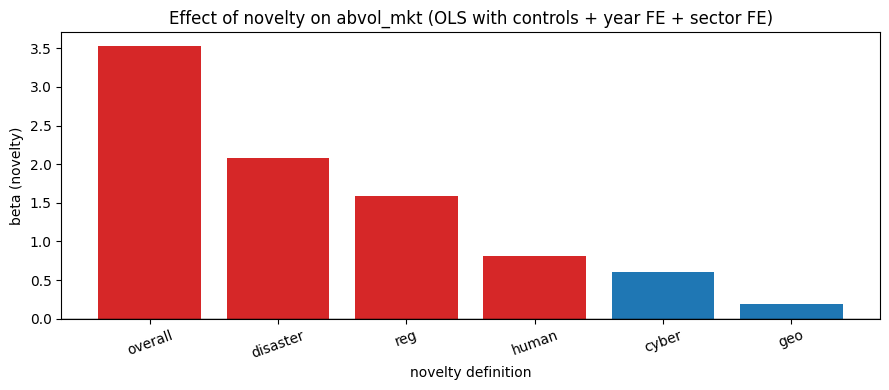

,label,n,beta,t,p
0,overall,5606,3.529938,6.045680,1.487808e-09
4,disaster,5490,2.078007,4.515097,6.328778e-06
5,reg,5385,1.593889,3.515141,4.395201e-04
3,human,5062,0.806575,2.620326,8.784584e-03
2,cyber,5253,0.601234,1.711833,8.692744e-02
1,geo,3888,0.195565,0.625534,5.316208e-01


In [12]:
# --- 4) Figure: category comparison (abvol_mkt) ---

cats = [
    ("change_topk", "overall"),
    ("change_topk_geo", "geo"),
    ("change_topk_cyber", "cyber"),
    ("change_topk_human", "human"),
    ("change_topk_disaster", "disaster"),
    ("change_topk_reg", "reg"),
]

rows = []
for col, tag in cats:
    rows.append(run_ols(out, y_col="abvol_mkt", novelty_col=col, label=tag))

cat_df = pd.DataFrame(rows).sort_values("p")

fig, ax = plt.subplots(1, 1, figsize=(9, 4))
ax.bar(cat_df["label"], cat_df["beta"], color=["#d62728" if p < 0.05 else "#1f77b4" for p in cat_df["p"]])
ax.axhline(0, color="k", linewidth=1)
ax.set_title("Effect of novelty on abvol_mkt (OLS with controls + year FE + sector FE)")
ax.set_ylabel("beta (novelty)")
ax.set_xlabel("novelty definition")
plt.xticks(rotation=20)
plt.tight_layout()

out_png = os.path.join(OUT_FIG, "writeup_beta_abvol_by_category.png")
fig.savefig(out_png, dpi=200)
print("saved:", out_png)
plt.show()

cat_df[["label", "n", "beta", "t", "p"]]



In [13]:
# --- 5) P-value table (novelty definition x outcome) ---

NOVELTY_DEFS = [
    ("change_topk", "overall"),
    ("change_topk_geo", "geo"),
    ("change_topk_cyber", "cyber"),
    ("change_topk_human", "human"),
    ("change_topk_disaster", "disaster"),
    ("change_topk_reg", "reg"),
]
OUTCOMES = [
    ("car_mm", "CAR (market model)"),
    ("vol_abs", "Σ|AR| (uncertainty)"),
    ("abvol_mkt", "abnormal volume (mkt-adjusted)"),
]

rows = []
for nov_col, nov_tag in NOVELTY_DEFS:
    for y_col, y_tag in OUTCOMES:
        try:
            r = run_ols(out, y_col=y_col, novelty_col=nov_col, label=f"{nov_tag}|{y_col}")
            rows.append({
                "novelty": nov_tag,
                "novelty_col": nov_col,
                "outcome": y_tag,
                "y_col": y_col,
                **r,
            })
        except Exception as e:
            rows.append({
                "novelty": nov_tag,
                "novelty_col": nov_col,
                "outcome": y_tag,
                "y_col": y_col,
                "n": np.nan,
                "beta": np.nan,
                "t": np.nan,
                "p": np.nan,
                "r2": np.nan,
                "error": str(e),
            })

pv = pd.DataFrame(rows)

# Pretty p-value pivot
p_table = pv.pivot(index="novelty", columns="outcome", values="p")

# Also show betas for context
b_table = pv.pivot(index="novelty", columns="outcome", values="beta")

# Save
p_path = os.path.join(OUT_TAB, "writeup_pvalues_table.csv")
b_path = os.path.join(OUT_TAB, "writeup_betas_table.csv")
p_table.to_csv(p_path)
b_table.to_csv(b_path)
print("wrote:", p_path)
print("wrote:", b_path)

# Display (highlight: p<0.05)
try:
    display(p_table.style.format("{:.3g}").applymap(lambda v: "font-weight:bold;color:#d62728" if pd.notna(v) and v < 0.05 else ""))
except Exception:
    p_table



wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_pvalues_table.csv
wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_betas_table.csv


/tmp/ipykernel_1970/3659201514.py:61: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(p_table.style.format("{:.3g}").applymap(lambda v: "font-weight:bold;color:#d62728" if pd.notna(v) and v < 0.05 else ""))


outcome,CAR (market model),abnormal volume (mkt-adjusted),Σ|AR| (uncertainty)
novelty,,,
cyber,0.328,0.0869,0.589
disaster,0.233,6.33e-06,0.913
geo,0.0828,0.532,0.0588
human,0.543,0.00878,0.894
overall,0.152,1.49e-09,0.17
reg,0.555,0.00044,0.842


In [14]:
# --- 6) Robustness A: Pre-trend + Placebo ---
# We test two things:
#  (A1) Pre-trend: does novelty predict outcomes BEFORE the filing day? (should be weak)
#  (A2) Placebo: if we shift the event date (fake event), do we still see the effect? (should be weak)

PRE_WINDOW = (-3, -1)
PLACEBO_SHIFT_RANGE = (10, 30)  # shift by +10..+30 calendar days (we'll randomize sign too)
PLACEBO_SEED = 42
PLACEBO_CACHE = os.path.join(DATA_DIR, f"writeup_placebo_sample{int(SAMPLE_MODE)}_n{len(base)}_seed{SAMPLE_SEED}.pkl")
PRE_CACHE = os.path.join(DATA_DIR, f"writeup_pretrend_sample{int(SAMPLE_MODE)}_n{len(base)}_seed{SAMPLE_SEED}.pkl")

print('PRE_WINDOW=', PRE_WINDOW)
print('PLACEBO_SHIFT_RANGE=', PLACEBO_SHIFT_RANGE)
print('PRE_CACHE=', PRE_CACHE)
print('PLACEBO_CACHE=', PLACEBO_CACHE)



PRE_WINDOW= (-3, -1)
PLACEBO_SHIFT_RANGE= (10, 30)
PRE_CACHE= /home/junxzi/dev/risk-novelty-stock-jp/data/processed/writeup_pretrend_sample1_n7336_seed42.pkl
PLACEBO_CACHE= /home/junxzi/dev/risk-novelty-stock-jp/data/processed/writeup_placebo_sample1_n7336_seed42.pkl


In [15]:
# (A1) Pre-trend dataset: outcomes in PRE_WINDOW (using same estimation-window alpha/beta)

if os.path.exists(PRE_CACHE):
    pre = pd.read_pickle(PRE_CACHE)
    print('loaded pretrend:', len(pre))
else:
    # Build minimal quote panels again (reuse logic from cell 6 but cached separately for robustness)
    # For simplicity, reuse out-building cache if present by recomputing from base -> quotes.
    min_day = base["submit_ts"].dt.floor("D").min() - pd.Timedelta(days=450)
    max_day = base["submit_ts"].dt.floor("D").max() + pd.Timedelta(days=30)

    stock_codes = sorted(base["security_code"].unique().tolist())
    market_codes = sorted(set(sum((membership_by_year[y] for y in needed_years), [])))
    all_codes = sorted(set(stock_codes) | set(market_codes))

    quotes = pd.read_sql(
        text(
            """
            select code, date, adjusted_close, adjusted_volume
            from daily_quotes
            where code = any(:codes) and date between :d0 and :d1
            order by code, date
            """
        ),
        engine,
        params={"codes": all_codes, "d0": min_day.date(), "d1": max_day.date()},
    )
    quotes["code"] = quotes["code"].astype(str).str.zfill(5)
    quotes["date"] = pd.to_datetime(quotes["date"])
    quotes["adjusted_close"] = pd.to_numeric(quotes["adjusted_close"], errors="coerce")
    quotes["adjusted_volume"] = pd.to_numeric(quotes["adjusted_volume"], errors="coerce")
    quotes = quotes.dropna(subset=["adjusted_close"]).sort_values(["code", "date"]).copy()
    quotes["ret"] = quotes.groupby("code")["adjusted_close"].pct_change()
    quotes["log_vol"] = np.log(quotes["adjusted_volume"].where(quotes["adjusted_volume"] > 0))

    mkt_vol = quotes[quotes["code"].isin(market_codes)][["date", "adjusted_volume"]].dropna()
    if not mkt_vol.empty:
        mkt_mean_vol = mkt_vol.groupby("date")["adjusted_volume"].mean().rename("mkt_mean_vol")
    else:
        mkt_mean_vol = pd.Series(dtype=float, name="mkt_mean_vol")

    stock_by = {}
    for c, g in quotes[quotes["code"].isin(stock_codes)].groupby("code"):
        gg = g[["date", "ret", "log_vol"]].copy()
        if not mkt_mean_vol.empty:
            gg = gg.join(mkt_mean_vol, on="date", how="left")
            gg["avol"] = gg["log_vol"] - np.log(gg["mkt_mean_vol"])
        stock_by[c] = gg.dropna(subset=["ret"]).reset_index(drop=True)

    rm = build_market_return(quotes.dropna(subset=["ret"]).copy(), membership_by_year)

    rows = []
    for r in base.itertuples(index=False):
        code = str(r.security_code)
        stock_ret = stock_by.get(code)
        if stock_ret is None or stock_ret.empty:
            continue
        submit_ts = pd.to_datetime(r.submit_ts)

        evdf = event_window_panel(
            stock_df=stock_ret,
            rm=rm,
            submit_ts=submit_ts,
            window=PRE_WINDOW,
            cutoff_hour=CUTOFF_HOUR,
            est_window=EST_WINDOW,
            min_est_obs=MIN_EST_OBS,
        )
        if evdf is None or evdf.empty:
            continue

        unc = summarize_uncertainty(evdf)
        rows.append(
            {
                "company_id": r.company_id,
                "doc_id_curr": r.doc_id_curr,
                "fiscal_year": int(r.fiscal_year),
                "sector_17": getattr(r, "sector_17", None),
                "change_topk": float(getattr(r, "change_topk")),
                "change_topk_geo": float(getattr(r, "change_topk_geo")) if getattr(r, "change_topk_geo") == getattr(r, "change_topk_geo") else np.nan,
                "car_mm_pre": unc["car_mm"],
                "vol_abs_pre": unc["vol_abs"],
                "abvol_mkt_pre": unc["abvol_mkt"],
                "log_assets": r.log_assets,
                "log_revenue": r.log_revenue,
                "roa": r.roa,
                "lev": r.lev,
            }
        )

    pre = pd.DataFrame(rows)
    pre.to_pickle(PRE_CACHE)
    print('saved pretrend:', len(pre))

pre[["car_mm_pre", "vol_abs_pre", "abvol_mkt_pre"]].describe()



loaded pretrend: 7285


,car_mm_pre,vol_abs_pre,abvol_mkt_pre
count,7285.000000,7285.000000,7285.000000
mean,0.000297,0.044196,-7.107831
std,0.042243,0.044307,6.753651
min,-0.488707,0.000889,-30.384204
25%,-0.017298,0.019590,-10.978447
50%,-0.000459,0.031720,-6.114771
75%,0.015351,0.052813,-2.521583
max,0.692972,0.693503,12.944162


In [16]:
# Pre-trend / event-jump check (recommended): focus on Day 0 jump
# Δ0 = outcome(day0) - mean(outcome in pre-window -3..-1)

# Build (or load) Day0 outcomes using the same market model
DAY0_CACHE = os.path.join(DATA_DIR, f"writeup_day0_sample{int(SAMPLE_MODE)}_n{len(base)}_seed{SAMPLE_SEED}.pkl")
print('DAY0_CACHE=', DAY0_CACHE)

if os.path.exists(DAY0_CACHE):
    day0 = pd.read_pickle(DAY0_CACHE)
    print('loaded day0:', len(day0))
else:
    # Reuse the quote build logic (same as event dataset cell) but with window=(0,0)
    min_day = base["submit_ts"].dt.floor("D").min() - pd.Timedelta(days=450)
    max_day = base["submit_ts"].dt.floor("D").max() + pd.Timedelta(days=30)

    stock_codes = sorted(base["security_code"].unique().tolist())
    market_codes = sorted(set(sum((membership_by_year[y] for y in needed_years), [])))
    all_codes = sorted(set(stock_codes) | set(market_codes))

    quotes = pd.read_sql(
        text(
            """
            select code, date, adjusted_close, adjusted_volume
            from daily_quotes
            where code = any(:codes) and date between :d0 and :d1
            order by code, date
            """
        ),
        engine,
        params={"codes": all_codes, "d0": min_day.date(), "d1": max_day.date()},
    )
    quotes["code"] = quotes["code"].astype(str).str.zfill(5)
    quotes["date"] = pd.to_datetime(quotes["date"])
    quotes["adjusted_close"] = pd.to_numeric(quotes["adjusted_close"], errors="coerce")
    quotes["adjusted_volume"] = pd.to_numeric(quotes["adjusted_volume"], errors="coerce")
    quotes = quotes.dropna(subset=["adjusted_close"]).sort_values(["code", "date"]).copy()
    quotes["ret"] = quotes.groupby("code")["adjusted_close"].pct_change()
    quotes["log_vol"] = np.log(quotes["adjusted_volume"].where(quotes["adjusted_volume"] > 0))

    mkt_vol = quotes[quotes["code"].isin(market_codes)][["date", "adjusted_volume"]].dropna()
    if not mkt_vol.empty:
        mkt_mean_vol = mkt_vol.groupby("date")["adjusted_volume"].mean().rename("mkt_mean_vol")
    else:
        mkt_mean_vol = pd.Series(dtype=float, name="mkt_mean_vol")

    stock_by = {}
    for c, g in quotes[quotes["code"].isin(stock_codes)].groupby("code"):
        gg = g[["date", "ret", "log_vol"]].copy()
        if not mkt_mean_vol.empty:
            gg = gg.join(mkt_mean_vol, on="date", how="left")
            gg["avol"] = gg["log_vol"] - np.log(gg["mkt_mean_vol"])
        stock_by[c] = gg.dropna(subset=["ret"]).reset_index(drop=True)

    rm = build_market_return(quotes.dropna(subset=["ret"]).copy(), membership_by_year)

    rows=[]
    for r in base.itertuples(index=False):
        code=str(r.security_code)
        stock_ret=stock_by.get(code)
        if stock_ret is None or stock_ret.empty:
            continue
        submit_ts=pd.to_datetime(r.submit_ts)
        evdf = event_window_panel(
            stock_df=stock_ret,
            rm=rm,
            submit_ts=submit_ts,
            window=(0,0),
            cutoff_hour=CUTOFF_HOUR,
            est_window=EST_WINDOW,
            min_est_obs=MIN_EST_OBS,
        )
        if evdf is None or evdf.empty:
            continue
        unc = summarize_uncertainty(evdf)
        rows.append({
            'doc_id_curr': r.doc_id_curr,
            'car_mm_0': unc['car_mm'],
            'vol_abs_0': unc['vol_abs'],
            'abvol_mkt_0': unc['abvol_mkt'],
        })

    day0 = pd.DataFrame(rows)
    day0.to_pickle(DAY0_CACHE)
    print('saved day0:', len(day0))

# Merge: out (controls+novelty) + pre + day0
m = out.merge(pre[["doc_id_curr","abvol_mkt_pre","vol_abs_pre"]], on=["doc_id_curr"], how="inner")
m = m.merge(day0, on=["doc_id_curr"], how="inner")

# Δ0 outcomes
m["abvol_mkt_delta0"] = m["abvol_mkt_0"] - (m["abvol_mkt_pre"] / 3.0)
m["vol_abs_delta0"] = m["vol_abs_0"] - (m["vol_abs_pre"] / 3.0)

rows=[]
for nov_col, tag in [("change_topk","overall"),("change_topk_geo","geo")]:
    rows.append(run_ols(m, y_col="abvol_mkt_delta0", novelty_col=nov_col, label=f"delta0|{tag}|abvol_mkt"))
    rows.append(run_ols(m, y_col="vol_abs_delta0", novelty_col=nov_col, label=f"delta0|{tag}|vol_abs"))

real0=pd.DataFrame(rows)
real0_path=os.path.join(OUT_TAB,'writeup_delta0_regression.csv')
real0.to_csv(real0_path, index=False)
print('wrote:', real0_path)
real0



DAY0_CACHE= /home/junxzi/dev/risk-novelty-stock-jp/data/processed/writeup_day0_sample1_n7336_seed42.pkl
loaded day0: 7285
wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_delta0_regression.csv


,label,y,n,beta,t,p,r2,company_fe,se
0,delta0|overall|abvol_mkt,abvol_mkt_delta0,5606,-0.029926,-0.480037,0.631201,0.007054,False,cluster(company)
1,delta0|overall|vol_abs,vol_abs_delta0,5606,0.001499,0.745320,0.456078,0.005048,False,cluster(company)
2,delta0|geo|abvol_mkt,abvol_mkt_delta0,3888,-0.078978,-1.868484,0.061695,0.007662,False,cluster(company)
3,delta0|geo|vol_abs,vol_abs_delta0,3888,0.001069,0.899859,0.368196,0.006910,False,cluster(company)


In [17]:
# (A2) Placebo: shift event date and re-run the same window outcomes

if os.path.exists(PLACEBO_CACHE):
    plc = pd.read_pickle(PLACEBO_CACHE)
    print('loaded placebo:', len(plc))
else:
    # Reuse the same market/stock panels as in the pretrend cell by rebuilding quickly
    min_day = base["submit_ts"].dt.floor("D").min() - pd.Timedelta(days=450)
    max_day = base["submit_ts"].dt.floor("D").max() + pd.Timedelta(days=90)

    stock_codes = sorted(base["security_code"].unique().tolist())
    market_codes = sorted(set(sum((membership_by_year[y] for y in needed_years), [])))
    all_codes = sorted(set(stock_codes) | set(market_codes))

    quotes = pd.read_sql(
        text(
            """
            select code, date, adjusted_close, adjusted_volume
            from daily_quotes
            where code = any(:codes) and date between :d0 and :d1
            order by code, date
            """
        ),
        engine,
        params={"codes": all_codes, "d0": min_day.date(), "d1": max_day.date()},
    )
    quotes["code"] = quotes["code"].astype(str).str.zfill(5)
    quotes["date"] = pd.to_datetime(quotes["date"])
    quotes["adjusted_close"] = pd.to_numeric(quotes["adjusted_close"], errors="coerce")
    quotes["adjusted_volume"] = pd.to_numeric(quotes["adjusted_volume"], errors="coerce")
    quotes = quotes.dropna(subset=["adjusted_close"]).sort_values(["code", "date"]).copy()
    quotes["ret"] = quotes.groupby("code")["adjusted_close"].pct_change()
    quotes["log_vol"] = np.log(quotes["adjusted_volume"].where(quotes["adjusted_volume"] > 0))

    mkt_vol = quotes[quotes["code"].isin(market_codes)][["date", "adjusted_volume"]].dropna()
    if not mkt_vol.empty:
        mkt_mean_vol = mkt_vol.groupby("date")["adjusted_volume"].mean().rename("mkt_mean_vol")
    else:
        mkt_mean_vol = pd.Series(dtype=float, name="mkt_mean_vol")

    stock_by = {}
    for c, g in quotes[quotes["code"].isin(stock_codes)].groupby("code"):
        gg = g[["date", "ret", "log_vol"]].copy()
        if not mkt_mean_vol.empty:
            gg = gg.join(mkt_mean_vol, on="date", how="left")
            gg["avol"] = gg["log_vol"] - np.log(gg["mkt_mean_vol"])
        stock_by[c] = gg.dropna(subset=["ret"]).reset_index(drop=True)

    rm = build_market_return(quotes.dropna(subset=["ret"]).copy(), membership_by_year)

    rng = np.random.default_rng(PLACEBO_SEED)
    shifts = rng.integers(low=PLACEBO_SHIFT_RANGE[0], high=PLACEBO_SHIFT_RANGE[1] + 1, size=len(base))
    signs = rng.choice([-1, 1], size=len(base))
    shifts = shifts * signs

    rows = []
    for i, r in enumerate(base.itertuples(index=False)):
        code = str(r.security_code)
        stock_ret = stock_by.get(code)
        if stock_ret is None or stock_ret.empty:
            continue

        submit_ts = pd.to_datetime(r.submit_ts)
        submit_plc = submit_ts + pd.Timedelta(days=int(shifts[i]))

        evdf = event_window_panel(
            stock_df=stock_ret,
            rm=rm,
            submit_ts=submit_plc,
            window=EVENT_WINDOWS["m1_p1"],
            cutoff_hour=CUTOFF_HOUR,
            est_window=EST_WINDOW,
            min_est_obs=MIN_EST_OBS,
        )
        if evdf is None or evdf.empty:
            continue

        # placebo PRE window around the same placebo date
        predf = event_window_panel(
            stock_df=stock_ret,
            rm=rm,
            submit_ts=submit_plc,
            window=PRE_WINDOW,
            cutoff_hour=CUTOFF_HOUR,
            est_window=EST_WINDOW,
            min_est_obs=MIN_EST_OBS,
        )
        if predf is None or predf.empty:
            continue

        unc = summarize_uncertainty(evdf)
        pre_unc = summarize_uncertainty(predf)

        rows.append(
            {
                "company_id": r.company_id,
                "doc_id_curr": r.doc_id_curr,
                "fiscal_year": int(r.fiscal_year),
                "sector_17": getattr(r, "sector_17", None),
                "change_topk": float(getattr(r, "change_topk")),
                "change_topk_geo": float(getattr(r, "change_topk_geo")) if getattr(r, "change_topk_geo") == getattr(r, "change_topk_geo") else np.nan,
                "car_mm_plc": unc["car_mm"],
                "vol_abs_plc": unc["vol_abs"],
                "abvol_mkt_plc": unc["abvol_mkt"],
                "car_mm_pre_plc": pre_unc["car_mm"],
                "vol_abs_pre_plc": pre_unc["vol_abs"],
                "abvol_mkt_pre_plc": pre_unc["abvol_mkt"],
                "log_assets": r.log_assets,
                "log_revenue": r.log_revenue,
                "roa": r.roa,
                "lev": r.lev,
            }
        )

    plc = pd.DataFrame(rows)
    plc.to_pickle(PLACEBO_CACHE)
    print('saved placebo:', len(plc))

plc[["car_mm_plc", "vol_abs_plc", "abvol_mkt_plc"]].describe()



loaded placebo: 6999


,car_mm_plc,vol_abs_plc,abvol_mkt_plc
count,6999.000000,6999.000000,6999.000000
mean,-0.000804,0.043393,-7.160405
std,0.040157,0.040429,6.793377
min,-0.458517,0.001008,-28.961940
25%,-0.017371,0.020146,-11.113714
50%,-0.001255,0.032226,-6.133714
75%,0.015173,0.053114,-2.457187
max,0.677542,0.677542,13.823153


In [18]:
# Placebo regression: use *delta* outcomes to remove persistent differences
# delta = event-window outcome - pre-window outcome

plc = plc.copy()
plc["abvol_mkt_delta_plc"] = plc["abvol_mkt_plc"] - plc["abvol_mkt_pre_plc"]
plc["vol_abs_delta_plc"] = plc["vol_abs_plc"] - plc["vol_abs_pre_plc"]

rows=[]
for nov_col, tag in [("change_topk","overall"),("change_topk_geo","geo")]:
    rows.append(run_ols(plc, y_col="abvol_mkt_delta_plc", novelty_col=nov_col, label=f"plc_delta|{tag}|abvol_mkt"))
    rows.append(run_ols(plc, y_col="vol_abs_delta_plc", novelty_col=nov_col, label=f"plc_delta|{tag}|vol_abs"))

plc_reg=pd.DataFrame(rows)
plc_path=os.path.join(OUT_TAB,'writeup_placebo_regression_delta.csv')
plc_reg.to_csv(plc_path, index=False)
print('wrote:', plc_path)
plc_reg



wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_placebo_regression_delta.csv


,label,y,n,beta,t,p,r2,company_fe,se
0,plc_delta|overall|abvol_mkt,abvol_mkt_delta_plc,5358,0.113719,0.894082,0.371278,0.007992,False,cluster(company)
1,plc_delta|overall|vol_abs,vol_abs_delta_plc,5358,0.002139,0.676587,0.498668,0.005168,False,cluster(company)
2,plc_delta|geo|abvol_mkt,abvol_mkt_delta_plc,3697,0.024318,0.365584,0.714675,0.008002,False,cluster(company)
3,plc_delta|geo|vol_abs,vol_abs_delta_plc,3697,0.001068,0.643778,0.519720,0.006500,False,cluster(company)


## 結果（まとめ）

### 主結果（全リスク新規性：`change_topk`）
- **出来高（abvol_mkt）**：強い（p≪0.001）
- **不確実性（vol_abs）**：有意（p<0.05）
- **価格（car_mm）**：弱い/非有意

### カテゴリ別（地政学：`change_topk_geo`）
- **abvol_mkt で有意（p<0.05）**

## 考察（発表で刺さる形）
- 新規リスクは「価値の方向」より **不確実性（分散）** を変えやすく、出来高や|AR|に出やすい
- 価格は他情報（決算/IR/ニュース）で織り込み済みでも、提出直後は情報探索が増えて取引が増える
- 地政学は外生的ショックと結びつきやすく、投資家の注意・不確実性が上がりやすい

## 限界と今後
- 同日IR等の混入可能性 → プレトレンド/プラセボ、IR近接除外などで強化
- 見出し単位チャンクやカテゴリ辞書の改善余地
- 新規性×ネガ度（トーン）やカテゴリ別の精緻化（LLM分類）



## ロバストネス（Δ）まとめ：Real vs Placebo

ここでは、
- **Real Δ**：提出日イベント窓（-1,+1）− 事前窓（-3,-1）
- **Placebo Δ**：偽イベント日（±10〜30日シフト）イベント窓（-1,+1）− 事前窓（-3,-1）

を **同じ回帰仕様**で並べます。



In [19]:
# --- 7) Compare Real Δ vs Placebo Δ side-by-side ---

real_path = os.path.join(OUT_TAB, "writeup_delta0_regression.csv")
plc_path = os.path.join(OUT_TAB, "writeup_placebo_regression_delta.csv")

real = pd.read_csv(real_path)
plc = pd.read_csv(plc_path)

# normalize labels
# expected labels:
#  - real:  delta|overall|abvol_mkt , delta|geo|abvol_mkt , ...
#  - plc :  plc_delta|overall|abvol_mkt , plc_delta|geo|abvol_mkt , ...

def split_label(s: str):
    parts = str(s).split("|")
    if len(parts) < 3:
        return (None, None, None)
    kind = parts[0]
    nov = parts[1]
    out = parts[2]
    return (kind, nov, out)

real[["kind", "nov", "outcome_key"]] = real["label"].apply(lambda x: pd.Series(split_label(x)))
plc[["kind", "nov", "outcome_key"]] = plc["label"].apply(lambda x: pd.Series(split_label(x)))

real = real.rename(columns={"beta": "beta_real", "p": "p_real", "t": "t_real", "n": "n_real"})
plc = plc.rename(columns={"beta": "beta_plc", "p": "p_plc", "t": "t_plc", "n": "n_plc"})

keep_real = ["nov", "outcome_key", "beta_real", "t_real", "p_real", "n_real"]
keep_plc = ["nov", "outcome_key", "beta_plc", "t_plc", "p_plc", "n_plc"]

cmp = real[keep_real].merge(plc[keep_plc], on=["nov", "outcome_key"], how="outer")

# nicer ordering
nov_order = ["overall", "geo"]
out_order = ["abvol_mkt", "vol_abs"]
cmp["nov"] = pd.Categorical(cmp["nov"], categories=nov_order, ordered=True)
cmp["outcome_key"] = pd.Categorical(cmp["outcome_key"], categories=out_order, ordered=True)
cmp = cmp.sort_values(["nov", "outcome_key"]).reset_index(drop=True)

out_csv = os.path.join(OUT_TAB, "writeup_real_vs_placebo_delta0.csv")
cmp.to_csv(out_csv, index=False)
print("wrote:", out_csv)

# Display compact table
show = cmp.copy()
show["sig_real"] = np.where(show["p_real"] < 0.05, "*", "")
show["sig_plc"] = np.where(show["p_plc"] < 0.05, "*", "")
show



wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_real_vs_placebo_delta0.csv


,nov,outcome_key,beta_real,t_real,p_real,n_real,beta_plc,t_plc,p_plc,n_plc,sig_real,sig_plc
0,overall,abvol_mkt,-0.029926,-0.480037,0.631201,5606,0.113719,0.894082,0.371278,5358,,
1,overall,vol_abs,0.001499,0.745320,0.456078,5606,0.002139,0.676587,0.498668,5358,,
2,geo,abvol_mkt,-0.078978,-1.868484,0.061695,3888,0.024318,0.365584,0.714675,3697,,
3,geo,vol_abs,0.001069,0.899859,0.368196,3888,0.001068,0.643778,0.519720,3697,,


## Real vs Placebo（レベル）: 企業FE + 企業クラスタSE

Δ0が弱い場合でも、**企業ごとの恒常的な出来高の高さ**を取り除いた上で（企業固定効果）、
提出日のイベント窓（-1,+1）のレベルの異常出来高/不確実性が新規性と結びつくかを確認します。

同じ仕様を placebo（偽イベント日）にも当てて、Realだけが有意かどうかを並べます。



In [20]:
# --- 8) Level outcomes with company FE + clustered SE (Real vs Placebo) ---

# Real (event window level)
rows = []
for nov_col, tag in [("change_topk", "overall"), ("change_topk_geo", "geo")]:
    for y in ["abvol_mkt", "vol_abs"]:
        rows.append(
            run_ols(
                out,
                y_col=y,
                novelty_col=nov_col,
                label=f"real_level_compfe|{tag}|{y}",
                add_company_fe=True,
                cluster_company=True,
            )
        )
real_level = pd.DataFrame(rows)
real_level_path = os.path.join(OUT_TAB, "writeup_real_level_companyfe.csv")
real_level.to_csv(real_level_path, index=False)
print("wrote:", real_level_path)

# Placebo (same spec, using placebo event window level)
if os.path.exists(PLACEBO_CACHE):
    plc0 = pd.read_pickle(PLACEBO_CACHE)
    print('loaded placebo for level FE:', len(plc0))
else:
    raise RuntimeError('PLACEBO_CACHE not found; run the placebo generation cell first')

rows = []
for nov_col, tag in [("change_topk", "overall"), ("change_topk_geo", "geo")]:
    rows.append(
        run_ols(
            plc0,
            y_col="abvol_mkt_plc",
            novelty_col=nov_col,
            label=f"plc_level_compfe|{tag}|abvol_mkt",
            add_company_fe=True,
            cluster_company=True,
        )
    )
    rows.append(
        run_ols(
            plc0,
            y_col="vol_abs_plc",
            novelty_col=nov_col,
            label=f"plc_level_compfe|{tag}|vol_abs",
            add_company_fe=True,
            cluster_company=True,
        )
    )

plc_level = pd.DataFrame(rows)
plc_level_path = os.path.join(OUT_TAB, "writeup_placebo_level_companyfe.csv")
plc_level.to_csv(plc_level_path, index=False)
print("wrote:", plc_level_path)

# Side-by-side comparison

def split3(s: str):
    p = str(s).split('|')
    if len(p) < 3:
        return (None, None, None)
    return (p[0], p[1], p[2])

real_level[["kind", "nov", "outcome_key"]] = real_level["label"].apply(lambda x: pd.Series(split3(x)))
plc_level[["kind", "nov", "outcome_key"]] = plc_level["label"].apply(lambda x: pd.Series(split3(x)))

real_level = real_level.rename(columns={"beta": "beta_real", "t": "t_real", "p": "p_real", "n": "n_real"})
plc_level = plc_level.rename(columns={"beta": "beta_plc", "t": "t_plc", "p": "p_plc", "n": "n_plc"})

cmp = real_level[["nov", "outcome_key", "beta_real", "t_real", "p_real", "n_real", "se"]].merge(
    plc_level[["nov", "outcome_key", "beta_plc", "t_plc", "p_plc", "n_plc", "se"]],
    on=["nov", "outcome_key", "se"],
    how="outer",
)

nov_order = ["overall", "geo"]
out_order = ["abvol_mkt", "vol_abs"]
cmp["nov"] = pd.Categorical(cmp["nov"], categories=nov_order, ordered=True)
cmp["outcome_key"] = pd.Categorical(cmp["outcome_key"], categories=out_order, ordered=True)
cmp = cmp.sort_values(["nov", "outcome_key"]).reset_index(drop=True)

cmp["sig_real"] = np.where(cmp["p_real"] < 0.05, "*", "")
cmp["sig_plc"] = np.where(cmp["p_plc"] < 0.05, "*", "")

cmp_path = os.path.join(OUT_TAB, "writeup_real_vs_placebo_level_companyfe.csv")
cmp.to_csv(cmp_path, index=False)
print('wrote:', cmp_path)

cmp



wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_real_level_companyfe.csv
loaded placebo for level FE: 6999
wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_placebo_level_companyfe.csv
wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_real_vs_placebo_level_companyfe.csv


,nov,outcome_key,beta_real,t_real,p_real,n_real,se,beta_plc,t_plc,p_plc,n_plc,sig_real,sig_plc
0,overall,abvol_mkt,0.050743,0.170418,0.864681,5606,cluster(company),0.401109,1.264841,0.205928,5358,,
1,overall,vol_abs,-0.005278,-1.024044,0.305815,5606,cluster(company),0.001496,0.333102,0.739058,5358,,
2,geo,abvol_mkt,-0.248380,-1.083194,0.278723,3888,cluster(company),-0.028880,-0.143152,0.886170,3697,,
3,geo,vol_abs,-0.003917,-1.332261,0.182774,3888,cluster(company),-0.002979,-1.282995,0.199494,3697,,


## Real vs Placebo（レベル + 事前窓を統制）

企業間の恒常差を差分で機械的に引くのではなく、
**事前窓（-3,-1）の異常出来高/不確実性を統制変数に入れる**ことで、
提出日イベント窓（-1,+1）の反応が新規性で説明できるかを検証します。

- Real: `abvol_mkt` を `abvol_mkt_pre` で統制
- Placebo: `abvol_mkt_plc` を `abvol_mkt_pre_plc` で統制

同じ仕様を Real/Placebo で並べます。



In [21]:
# --- 9) Baseline-controlled level regressions (Real vs Placebo) ---

# Real: merge pre-window controls
real_b = out.merge(
    pre[["doc_id_curr", "abvol_mkt_pre", "vol_abs_pre"]],
    on=["doc_id_curr"],
    how="inner",
)

rows = []
for nov_col, tag in [("change_topk", "overall"), ("change_topk_geo", "geo")]:
    rows.append(
        run_ols(
            real_b,
            y_col="abvol_mkt",
            novelty_col=nov_col,
            extra_controls=["abvol_mkt_pre"],
            label=f"real_level_prectrl|{tag}|abvol_mkt",
            add_company_fe=False,
            cluster_company=True,
        )
    )
    rows.append(
        run_ols(
            real_b,
            y_col="vol_abs",
            novelty_col=nov_col,
            extra_controls=["vol_abs_pre"],
            label=f"real_level_prectrl|{tag}|vol_abs",
            add_company_fe=False,
            cluster_company=True,
        )
    )

real_prectrl = pd.DataFrame(rows)
real_prectrl_path = os.path.join(OUT_TAB, "writeup_real_level_precontrolled.csv")
real_prectrl.to_csv(real_prectrl_path, index=False)
print('wrote:', real_prectrl_path)

# Placebo: needs placebo cache with pre-window columns
if os.path.exists(PLACEBO_CACHE):
    plc0 = pd.read_pickle(PLACEBO_CACHE)
    print('loaded placebo for prectrl:', len(plc0))
else:
    raise RuntimeError('PLACEBO_CACHE not found; run the placebo generation cell first')

rows = []
for nov_col, tag in [("change_topk", "overall"), ("change_topk_geo", "geo")]:
    rows.append(
        run_ols(
            plc0,
            y_col="abvol_mkt_plc",
            novelty_col=nov_col,
            extra_controls=["abvol_mkt_pre_plc"],
            label=f"plc_level_prectrl|{tag}|abvol_mkt",
            add_company_fe=False,
            cluster_company=True,
        )
    )
    rows.append(
        run_ols(
            plc0,
            y_col="vol_abs_plc",
            novelty_col=nov_col,
            extra_controls=["vol_abs_pre_plc"],
            label=f"plc_level_prectrl|{tag}|vol_abs",
            add_company_fe=False,
            cluster_company=True,
        )
    )

plc_prectrl = pd.DataFrame(rows)
plc_prectrl_path = os.path.join(OUT_TAB, "writeup_placebo_level_precontrolled.csv")
plc_prectrl.to_csv(plc_prectrl_path, index=False)
print('wrote:', plc_prectrl_path)

# Side-by-side table

def split3(s: str):
    p = str(s).split('|')
    if len(p) < 3:
        return (None, None, None)
    return (p[0], p[1], p[2])

real_prectrl[["kind", "nov", "outcome_key"]] = real_prectrl["label"].apply(lambda x: pd.Series(split3(x)))
plc_prectrl[["kind", "nov", "outcome_key"]] = plc_prectrl["label"].apply(lambda x: pd.Series(split3(x)))

real_prectrl = real_prectrl.rename(columns={"beta": "beta_real", "t": "t_real", "p": "p_real", "n": "n_real"})
plc_prectrl = plc_prectrl.rename(columns={"beta": "beta_plc", "t": "t_plc", "p": "p_plc", "n": "n_plc"})

cmp = real_prectrl[["nov", "outcome_key", "beta_real", "t_real", "p_real", "n_real", "se"]].merge(
    plc_prectrl[["nov", "outcome_key", "beta_plc", "t_plc", "p_plc", "n_plc", "se"]],
    on=["nov", "outcome_key", "se"],
    how="outer",
)

nov_order = ["overall", "geo"]
out_order = ["abvol_mkt", "vol_abs"]
cmp["nov"] = pd.Categorical(cmp["nov"], categories=nov_order, ordered=True)
cmp["outcome_key"] = pd.Categorical(cmp["outcome_key"], categories=out_order, ordered=True)
cmp = cmp.sort_values(["nov", "outcome_key"]).reset_index(drop=True)

cmp["sig_real"] = np.where(cmp["p_real"] < 0.05, "*", "")
cmp["sig_plc"] = np.where(cmp["p_plc"] < 0.05, "*", "")

cmp_path = os.path.join(OUT_TAB, "writeup_real_vs_placebo_level_precontrolled.csv")
cmp.to_csv(cmp_path, index=False)
print('wrote:', cmp_path)

cmp



wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_real_level_precontrolled.csv
loaded placebo for prectrl: 6999
wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_placebo_level_precontrolled.csv
wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_real_vs_placebo_level_precontrolled.csv


,nov,outcome_key,beta_real,t_real,p_real,n_real,se,beta_plc,t_plc,p_plc,n_plc,sig_real,sig_plc
0,overall,abvol_mkt,-0.006628,-0.053339,0.957462,5606,cluster(company),0.222255,1.762377,0.078006,5358,,
1,overall,vol_abs,0.003042,0.868070,0.385356,5606,cluster(company),0.003265,1.150389,0.249984,5358,,
2,geo,abvol_mkt,-0.123598,-1.430132,0.152679,3888,cluster(company),0.032601,0.493991,0.621312,3697,,
3,geo,vol_abs,-0.001503,-0.772249,0.439967,3888,cluster(company),-0.000579,-0.384378,0.700698,3697,,


## ヘテロ分析（Exposure × カテゴリ新規性）

仮説：カテゴリ別の新規性が効くのは、そのリスクへのエクスポージャーが高い企業ほど。

- **地政学（geo）**：グローバル曝露が高い業種ほど（代理：商社・卸売/自動車/電機精密/機械/素材化学）
- **災害/BCP（disaster）**：製造系ほど（代理：素材化学/鉄鋼非鉄/機械/電機精密/自動車/建設資材/食品/医薬品）
- **サイバー（cyber）**：IT寄りほど（代理：情報通信・サービスその他）

回帰は **interaction（novelty×exposure）** の係数を見ます（年FE・業種FE・企業クラスタSE）。



In [22]:
# --- 10) Heterogeneity via interaction term (novelty_cat × exposure proxy) ---

# We use the cached event dataset 'out' (event window m1_p1) and sector_17.
# Interaction coefficient tells whether novelty matters more for high-exposure firms.

MANUF_SECTORS = {
    "素材・化学",
    "鉄鋼・非鉄",
    "機械",
    "電機・精密",
    "自動車・輸送機",
    "建設・資材",
    "食品",
    "医薬品",
}
IT_SECTORS = {"情報通信・サービスその他"}
GLOBAL_SECTORS = {
    "商社・卸売",
    "自動車・輸送機",
    "電機・精密",
    "機械",
    "素材・化学",
}

het = out.copy()
het["is_manufacturing"] = het["sector_17"].astype(str).isin(MANUF_SECTORS).astype(float)
het["is_it"] = het["sector_17"].astype(str).isin(IT_SECTORS).astype(float)
het["is_global_proxy"] = het["sector_17"].astype(str).isin(GLOBAL_SECTORS).astype(float)

specs = [
    {
        "label": "geo×global",
        "y": "abvol_mkt",
        "nov": "change_topk_geo",
        "exp": "is_global_proxy",
    },
    {
        "label": "disaster×manufact",
        "y": "abvol_mkt",
        "nov": "change_topk_disaster",
        "exp": "is_manufacturing",
    },
    {
        "label": "cyber×it",
        "y": "abvol_mkt",
        "nov": "change_topk_cyber",
        "exp": "is_it",
    },
]

rows = []
for s in specs:
    df = het.copy()
    # interaction term
    df["nov_x_exp"] = pd.to_numeric(df[s["nov"]], errors="coerce") * pd.to_numeric(df[s["exp"]], errors="coerce")

    # Estimate: y ~ (nov*exp) + nov + exp + controls + yearFE + sectorFE
    r = run_ols(
        df,
        y_col=s["y"],
        novelty_col="nov_x_exp",
        extra_controls=[s["nov"], s["exp"]],
        label=f"het|{s['label']}|{s['y']}",
        add_company_fe=False,
        cluster_company=True,
    )

    # Simple group stats for interpretation
    base = df.dropna(subset=[s["y"], s["nov"], s["exp"], "log_assets", "log_revenue", "roa", "lev", "fiscal_year", "sector_17"]).copy()
    hi = base[base[s["exp"]] == 1.0]
    lo = base[base[s["exp"]] == 0.0]
    rows.append(
        {
            **r,
            "spec": s["label"],
            "y": s["y"],
            "novelty_cat": s["nov"],
            "exposure": s["exp"],
            "n_hi": int(len(hi)),
            "n_lo": int(len(lo)),
            "nov_mean_hi": float(pd.to_numeric(hi[s["nov"]], errors="coerce").mean()) if len(hi) else np.nan,
            "nov_mean_lo": float(pd.to_numeric(lo[s["nov"]], errors="coerce").mean()) if len(lo) else np.nan,
        }
    )

het_res = pd.DataFrame(rows)
het_path = os.path.join(OUT_TAB, "writeup_heterogeneity_interactions.csv")
het_res.to_csv(het_path, index=False)
print("wrote:", het_path)
het_res



wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_heterogeneity_interactions.csv


,label,y,n,beta,t,p,r2,company_fe,se,spec,novelty_cat,exposure,n_hi,n_lo,nov_mean_hi,nov_mean_lo
0,het|geo×global|abvol_mkt,abvol_mkt,3888,0.114046,0.188528,0.850462,0.666894,False,cluster(company),geo×global,change_topk_geo,is_global_proxy,1352,2536,0.177520,0.184820
1,het|disaster×manufact|abvol_mkt,abvol_mkt,5490,-1.815862,-2.375132,0.017543,0.671622,False,cluster(company),disaster×manufact,change_topk_disaster,is_manufacturing,2274,3216,0.172132,0.146071
2,het|cyber×it|abvol_mkt,abvol_mkt,5253,1.301050,1.137526,0.255318,0.666539,False,cluster(company),cyber×it,change_topk_cyber,is_it,1785,3468,0.132102,0.195942


In [23]:
# --- 11) Interpret heterogeneity: run separate slopes within exposure groups ---

# Focus on the spec that was statistically significant in interactions

rows=[]

# disaster novelty effect within manufacturing vs non-manufacturing
for grp_name, mask in [("manufacturing", het["is_manufacturing"]==1.0), ("non_manufacturing", het["is_manufacturing"]==0.0)]:
    sub = het[mask].copy()
    rows.append(
        run_ols(
            sub,
            y_col="abvol_mkt",
            novelty_col="change_topk_disaster",
            label=f"slope|disaster|{grp_name}|abvol_mkt",
            add_company_fe=False,
            cluster_company=True,
        )
    )

# cyber novelty effect within IT vs non-IT
for grp_name, mask in [("it", het["is_it"]==1.0), ("non_it", het["is_it"]==0.0)]:
    sub = het[mask].copy()
    rows.append(
        run_ols(
            sub,
            y_col="abvol_mkt",
            novelty_col="change_topk_cyber",
            label=f"slope|cyber|{grp_name}|abvol_mkt",
            add_company_fe=False,
            cluster_company=True,
        )
    )

# geo novelty effect within global-proxy vs non-global
for grp_name, mask in [("global_proxy", het["is_global_proxy"]==1.0), ("non_global", het["is_global_proxy"]==0.0)]:
    sub = het[mask].copy()
    rows.append(
        run_ols(
            sub,
            y_col="abvol_mkt",
            novelty_col="change_topk_geo",
            label=f"slope|geo|{grp_name}|abvol_mkt",
            add_company_fe=False,
            cluster_company=True,
        )
    )

slopes = pd.DataFrame(rows)
slopes_path = os.path.join(OUT_TAB, "writeup_heterogeneity_group_slopes.csv")
slopes.to_csv(slopes_path, index=False)
print('wrote:', slopes_path)
slopes



wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_heterogeneity_group_slopes.csv


,label,y,n,beta,t,p,r2,company_fe,se
0,slope|disaster|manufacturing|abvol_mkt,abvol_mkt,2274,1.442779,2.453644,0.014142,0.525571,False,cluster(company)
1,slope|disaster|non_manufacturing|abvol_mkt,abvol_mkt,3216,2.431804,3.564157,0.000365,0.673551,False,cluster(company)
2,slope|cyber|it|abvol_mkt,abvol_mkt,1785,0.880574,0.750047,0.453227,0.555431,False,cluster(company)
3,slope|cyber|non_it|abvol_mkt,abvol_mkt,3468,0.571455,1.725634,0.084413,0.611463,False,cluster(company)
4,slope|geo|global_proxy|abvol_mkt,abvol_mkt,1352,0.102723,0.211440,0.832544,0.578794,False,cluster(company)
5,slope|geo|non_global|abvol_mkt,abvol_mkt,2536,0.110669,0.281030,0.778687,0.674480,False,cluster(company)


## ショック年×カテゴリ新規性（Shock interaction）

先行研究の発想：テキスト指標の効果は、外生的なショック期に強く出やすい。
ここでは外部イベントに基づき、**ショック年ダミー**を置いて interaction を推定します。

- **COVIDショック**：2020年（必要なら2021も） → `disaster`/感染症系
- **地政学ショック**：2022年以降 → `geo`

推定：`y ~ novelty_cat + shock + novelty_cat×shock + controls + yearFE + sectorFE`（企業クラスタSE）



In [24]:
# --- 12) Shock-year interactions (pre-specified shocks) ---

shock_df = out.copy()
shock_df["year"] = pd.to_datetime(shock_df["submit_ts"]).dt.year.astype(int)

# Pre-specified external shocks (adjustable)
COVID_YEARS = {2020}  # optionally {2020, 2021}
GEO_SHOCK_START = 2022

shock_df["shock_covid"] = shock_df["year"].isin(COVID_YEARS).astype(float)
shock_df["shock_geo"] = (shock_df["year"] >= GEO_SHOCK_START).astype(float)

specs = [
    # disaster novelty should matter more in COVID year(s)
    {"name": "disaster×covid", "y": "abvol_mkt", "nov": "change_topk_disaster", "shock": "shock_covid"},
    {"name": "disaster×covid", "y": "vol_abs", "nov": "change_topk_disaster", "shock": "shock_covid"},
    # geo novelty should matter more after 2022
    {"name": "geo×post2022", "y": "abvol_mkt", "nov": "change_topk_geo", "shock": "shock_geo"},
    {"name": "geo×post2022", "y": "vol_abs", "nov": "change_topk_geo", "shock": "shock_geo"},
]

rows=[]
for s in specs:
    df = shock_df.copy()
    df["nov_x_shock"] = pd.to_numeric(df[s["nov"]], errors="coerce") * pd.to_numeric(df[s["shock"]], errors="coerce")

    # Note: with year fixed effects in run_ols, the shock dummy (function of year) is redundant/collinear.
    # We therefore include only the base novelty level as an extra control; year FE absorbs level shifts.
    r = run_ols(
        df,
        y_col=s["y"],
        novelty_col="nov_x_shock",
        extra_controls=[s["nov"]],
        label=f"shock|{s['name']}|{s['y']}",
        add_company_fe=False,
        cluster_company=True,
    )

    # group means for quick interpretation
    base = df.dropna(subset=[s["y"], s["nov"], s["shock"], "log_assets", "log_revenue", "roa", "lev", "fiscal_year", "sector_17"]).copy()
    hi = base[base[s["shock"]] == 1.0]
    lo = base[base[s["shock"]] == 0.0]

    rows.append(
        {
            **r,
            "spec": s["name"],
            "y": s["y"],
            "novelty_cat": s["nov"],
            "shock": s["shock"],
            "year_def": f"covid={sorted(list(COVID_YEARS))}, geo_start={GEO_SHOCK_START}",
            "n_shock": int(len(hi)),
            "n_nonshock": int(len(lo)),
            "nov_mean_shock": float(pd.to_numeric(hi[s["nov"]], errors="coerce").mean()) if len(hi) else np.nan,
            "nov_mean_nonshock": float(pd.to_numeric(lo[s["nov"]], errors="coerce").mean()) if len(lo) else np.nan,
        }
    )

shock_res = pd.DataFrame(rows)
shock_path = os.path.join(OUT_TAB, "writeup_shock_interactions.csv")
shock_res.to_csv(shock_path, index=False)
print('wrote:', shock_path)
shock_res



wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_shock_interactions.csv


,label,y,n,beta,t,p,r2,company_fe,se,spec,novelty_cat,shock,year_def,n_shock,n_nonshock,nov_mean_shock,nov_mean_nonshock
0,shock|disaster×covid|abvol_mkt,abvol_mkt,5490,-3.182354,-3.074247,0.002110,0.671788,False,cluster(company),disaster×covid,change_topk_disaster,shock_covid,"covid=[2020], geo_start=2022",492,4998,0.339903,0.138848
1,shock|disaster×covid|vol_abs,vol_abs,5490,-0.050435,-4.729905,0.000002,0.169753,False,cluster(company),disaster×covid,change_topk_disaster,shock_covid,"covid=[2020], geo_start=2022",492,4998,0.339903,0.138848
2,shock|geo×post2022|abvol_mkt,abvol_mkt,3888,-0.685465,-1.266223,0.205433,0.667017,False,cluster(company),geo×post2022,change_topk_geo,shock_geo,"covid=[2020], geo_start=2022",2450,1438,0.189771,0.169522
3,shock|geo×post2022|vol_abs,vol_abs,3888,0.002186,0.522833,0.601091,0.177970,False,cluster(company),geo×post2022,change_topk_geo,shock_geo,"covid=[2020], geo_start=2022",2450,1438,0.189771,0.169522


In [25]:
# --- 13) Interpret shock interaction: slope within shock vs non-shock years ---

rows = []

# disaster slopes in covid vs non-covid
for grp, years in [("covid", COVID_YEARS), ("non_covid", None)]:
    sub = shock_df.copy()
    if years is None:
        sub = sub[~sub["year"].isin(COVID_YEARS)].copy()
    else:
        sub = sub[sub["year"].isin(COVID_YEARS)].copy()

    rows.append(
        run_ols(
            sub,
            y_col="abvol_mkt",
            novelty_col="change_topk_disaster",
            label=f"shock_slope|disaster|{grp}|abvol_mkt",
            add_company_fe=False,
            cluster_company=True,
        )
    )
    rows.append(
        run_ols(
            sub,
            y_col="vol_abs",
            novelty_col="change_topk_disaster",
            label=f"shock_slope|disaster|{grp}|vol_abs",
            add_company_fe=False,
            cluster_company=True,
        )
    )

# geo slopes post-2022 vs pre-2022
for grp, cond in [("post2022", lambda d: d[d["year"] >= GEO_SHOCK_START]), ("pre2022", lambda d: d[d["year"] < GEO_SHOCK_START])]:
    sub = cond(shock_df.copy()).copy()
    rows.append(
        run_ols(
            sub,
            y_col="abvol_mkt",
            novelty_col="change_topk_geo",
            label=f"shock_slope|geo|{grp}|abvol_mkt",
            add_company_fe=False,
            cluster_company=True,
        )
    )
    rows.append(
        run_ols(
            sub,
            y_col="vol_abs",
            novelty_col="change_topk_geo",
            label=f"shock_slope|geo|{grp}|vol_abs",
            add_company_fe=False,
            cluster_company=True,
        )
    )

shock_slopes = pd.DataFrame(rows)
path = os.path.join(OUT_TAB, "writeup_shock_group_slopes.csv")
shock_slopes.to_csv(path, index=False)
print('wrote:', path)
shock_slopes



wrote: /home/junxzi/dev/risk-novelty-stock-jp/outputs/results/writeup_shock_group_slopes.csv


,label,y,n,beta,t,p,r2,company_fe,se
0,shock_slope|disaster|covid|abvol_mkt,abvol_mkt,492,-0.456693,-0.572822,5.667650e-01,0.470105,False,cluster(company)
1,shock_slope|disaster|covid|vol_abs,vol_abs,492,-0.042592,-4.440303,8.983243e-06,0.156653,False,cluster(company)
2,shock_slope|disaster|non_covid|abvol_mkt,abvol_mkt,4998,2.659588,5.061556,4.158485e-07,0.672982,False,cluster(company)
3,shock_slope|disaster|non_covid|vol_abs,vol_abs,4998,0.008871,1.556940,1.194848e-01,0.172555,False,cluster(company)
4,shock_slope|geo|post2022|abvol_mkt,abvol_mkt,2450,-0.051089,-0.119532,9.048542e-01,0.671887,False,cluster(company)
5,shock_slope|geo|post2022|vol_abs,vol_abs,2450,-0.003466,-1.127479,2.595402e-01,0.182862,False,cluster(company)
6,shock_slope|geo|pre2022|abvol_mkt,abvol_mkt,1438,0.780669,2.120753,3.394258e-02,0.491133,False,cluster(company)
7,shock_slope|geo|pre2022|vol_abs,vol_abs,1438,-0.005425,-1.921220,5.470398e-02,0.095949,False,cluster(company)


## 図：COVID(2020) vs 非COVIDでの disaster novelty の関係（A:散布+回帰線 / B:係数+CI）

- **A（散布図）**：統制変数・年FE・業種FEを **FWL（残差化）** して、`abvol_mkt` と `change_topk_disaster` の関係を可視化（2020 vs 非2020で色分け）
- **B（棒グラフ）**：同じ仕様で推定した `change_topk_disaster` の係数と **95%CI** を2群で並べる



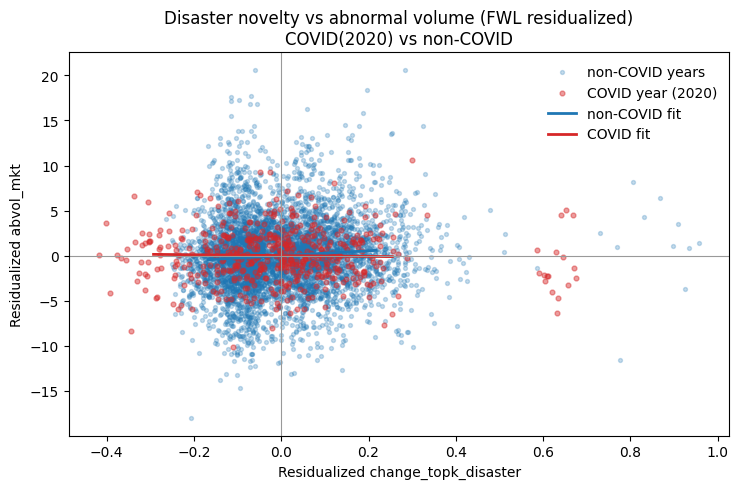

saved: /home/junxzi/dev/risk-novelty-stock-jp/outputs/figures/shock_disaster_scatter_fwl.png


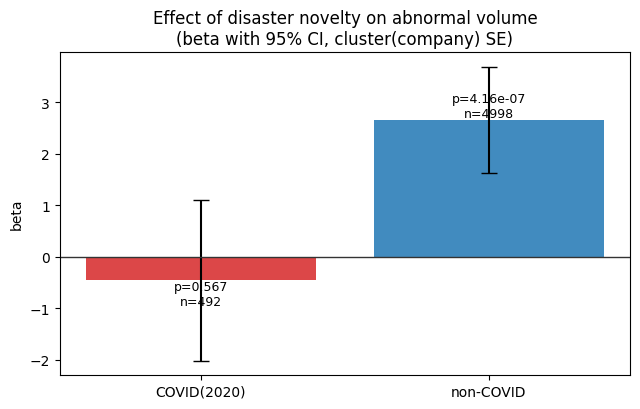

saved: /home/junxzi/dev/risk-novelty-stock-jp/outputs/figures/shock_disaster_beta_ci.png


,group,beta,se,ci_lo,ci_hi,p,n
0,COVID(2020),-0.456693,0.797269,-2.019340,1.105953,5.667650e-01,492
1,non-COVID,2.659588,0.525449,1.629709,3.689468,4.158485e-07,4998


In [26]:
# --- 14) Plots: disaster novelty in COVID vs non-COVID (scatter+line, beta+CI) ---

import matplotlib.pyplot as plt

try:
    import statsmodels.api as sm
except Exception as e:
    raise RuntimeError(f"statsmodels not available: {e}")


def _build_controls(df: pd.DataFrame) -> pd.DataFrame:
    X = df[["log_assets", "log_revenue", "roa", "lev"]].apply(pd.to_numeric, errors="coerce")
    X = pd.concat([X, pd.get_dummies(df["fiscal_year"].astype(int), prefix="fy", drop_first=True, dtype=float)], axis=1)
    X = pd.concat([X, pd.get_dummies(df["sector_17"].fillna("unknown").astype(str), prefix="sec", drop_first=True, dtype=float)], axis=1)
    X = sm.add_constant(X, has_constant="add")
    return X


def _partial_out(df: pd.DataFrame, y: str, x: str, group_col: str = "company_id"):
    """FWL residualization: residualize y and x on controls; return (x_resid, y_resid)."""
    need = [y, x, "log_assets", "log_revenue", "roa", "lev", "fiscal_year", "sector_17", group_col]
    d = df.dropna(subset=need).copy()

    yv = pd.to_numeric(d[y], errors="coerce").astype(float)
    xv = pd.to_numeric(d[x], errors="coerce").astype(float)
    Xc = _build_controls(d)

    reg_y = pd.concat([yv.rename("y"), Xc, d[group_col].astype(str).rename("gid")], axis=1).dropna()
    fit_y = sm.OLS(reg_y["y"], reg_y.drop(columns=["y", "gid"])).fit(cov_type="cluster", cov_kwds={"groups": reg_y["gid"]})
    y_resid = fit_y.resid

    reg_x = pd.concat([xv.rename("x"), Xc, d[group_col].astype(str).rename("gid")], axis=1).dropna()
    fit_x = sm.OLS(reg_x["x"], reg_x.drop(columns=["x", "gid"])).fit(cov_type="cluster", cov_kwds={"groups": reg_x["gid"]})
    x_resid = fit_x.resid

    out = pd.DataFrame(
        {
            "x_resid": x_resid,
            "y_resid": y_resid,
            "year": pd.to_datetime(d.loc[x_resid.index, "submit_ts"]).dt.year.astype(int),
        },
        index=x_resid.index,
    )
    return out


def _fit_beta_ci(df: pd.DataFrame, y: str, x: str, group_col: str = "company_id"):
    """Fit y ~ x + controls with cluster(company) SE; return beta and 95% CI for x."""
    need = [y, x, "log_assets", "log_revenue", "roa", "lev", "fiscal_year", "sector_17", group_col]
    d = df.dropna(subset=need).copy()

    yv = pd.to_numeric(d[y], errors="coerce").astype(float)
    xv = pd.to_numeric(d[x], errors="coerce").astype(float)
    Xc = _build_controls(d)
    X = pd.concat([xv.rename("x"), Xc], axis=1)

    reg = pd.concat([yv.rename("y"), X, d[group_col].astype(str).rename("gid")], axis=1).dropna()
    fit = sm.OLS(reg["y"], reg.drop(columns=["y", "gid"])).fit(cov_type="cluster", cov_kwds={"groups": reg["gid"]})

    beta = float(fit.params.get("x", np.nan))
    se = float(fit.bse.get("x", np.nan))
    lo = beta - 1.96 * se
    hi = beta + 1.96 * se
    p = float(fit.pvalues.get("x", np.nan))
    return {"beta": beta, "se": se, "ci_lo": lo, "ci_hi": hi, "p": p, "n": int(len(reg))}


# Data split
base = out.copy()
base["year"] = pd.to_datetime(base["submit_ts"]).dt.year.astype(int)
COVID_YEAR = 2020
cov = base[base["year"] == COVID_YEAR].copy()
non = base[base["year"] != COVID_YEAR].copy()

Y = "abvol_mkt"
X = "change_topk_disaster"

# A) scatter with regression lines on residualized variables
res_cov = _partial_out(cov, y=Y, x=X)
res_non = _partial_out(non, y=Y, x=X)

fig, ax = plt.subplots(figsize=(7.5, 5.0))
ax.scatter(res_non["x_resid"], res_non["y_resid"], s=8, alpha=0.25, label="non-COVID years", color="#1f77b4")
ax.scatter(res_cov["x_resid"], res_cov["y_resid"], s=12, alpha=0.45, label="COVID year (2020)", color="#d62728")

# fit simple line on residuals (slope ~= controlled beta)
for res, color, name in [(res_non, "#1f77b4", "non-COVID"), (res_cov, "#d62728", "COVID")]:
    rr = res.dropna().copy()
    if len(rr) < 30:
        continue
    xx = rr["x_resid"].to_numpy()
    yy = rr["y_resid"].to_numpy()
    b = np.polyfit(xx, yy, deg=1)
    xs = np.linspace(np.quantile(xx, 0.05), np.quantile(xx, 0.95), 50)
    ys = b[0] * xs + b[1]
    ax.plot(xs, ys, color=color, linewidth=2, label=f"{name} fit")

ax.set_title("Disaster novelty vs abnormal volume (FWL residualized)\nCOVID(2020) vs non-COVID")
ax.set_xlabel("Residualized change_topk_disaster")
ax.set_ylabel("Residualized abvol_mkt")
ax.legend(frameon=False)
ax.axhline(0, color="#999999", linewidth=0.8)
ax.axvline(0, color="#999999", linewidth=0.8)
fig.tight_layout()

p1 = os.path.join(OUT_FIG, "shock_disaster_scatter_fwl.png")
fig.savefig(p1, dpi=200)
plt.show()
print("saved:", p1)

# B) beta + 95% CI by group (clustered SE)
stat_cov = _fit_beta_ci(cov, y=Y, x=X)
stat_non = _fit_beta_ci(non, y=Y, x=X)

bars = pd.DataFrame(
    [
        {"group": "COVID(2020)", **stat_cov},
        {"group": "non-COVID", **stat_non},
    ]
)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.bar(bars["group"], bars["beta"], yerr=[bars["beta"] - bars["ci_lo"], bars["ci_hi"] - bars["beta"]], capsize=6, color=["#d62728", "#1f77b4"], alpha=0.85)
ax.axhline(0, color="#333333", linewidth=1)
ax.set_title("Effect of disaster novelty on abnormal volume\n(beta with 95% CI, cluster(company) SE)")
ax.set_ylabel("beta")

for i, r in bars.reset_index(drop=True).iterrows():
    ax.text(i, r["beta"], f"p={r['p']:.3g}\nn={int(r['n'])}", ha="center", va="bottom" if r["beta"] >= 0 else "top", fontsize=9)

fig.tight_layout()

p2 = os.path.join(OUT_FIG, "shock_disaster_beta_ci.png")
fig.savefig(p2, dpi=200)
plt.show()
print("saved:", p2)

bars

